# Section 1: Setup — Libraries, Configuration & Data Download

In [ ]:
%pip install -q "ultralytics>=8.3.0" kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.4 MB/s eta 0:00:00


In [ ]:
MODEL_NAME = "yolo11m-seg.pt"
QUICK_TEST = True
EPOCHS = 20
PATIENCE=15
IMGSZ=640
BATCH=8
USE_DRIVE=True
DRIVE_FOLDER = "/content/drive/MyDrive/vehide_seg"

DATASET=True
RUN_NAME="yolo11m_seg_vehide"
SEED=42
FORCE_RESTART=False
CLASS_NAMES = ["dent", "scratch", "crack", "broken_lamp", "shattered_glass", "flat_tyre"]
CLASS_MAP = {
    "mop_lom":     0,   # dent
    "tray_son":    1,   # scratch (paint)
    "rach":        1,   # scratch (torn body)
    "be_den":      3,   # broken_lamp
    "vo_kinh":     4,   # shattered_glass
    "thung":       5,   # flat_tyre
    "mat_bo_phan": -1
}

CLASS_COLORS = {        # one colour per class, used in every plot below
    0: "#E24A33", 1: "#348ABD", 2: "#988ED5",
    3: "#FBC15E", 4: "#8EBA42", 5: "#FFB5B8",
}

print("Model:      ", MODEL_NAME)
print("Quick test: ", QUICK_TEST)
print("Image size: ", IMGSZ, " Batch:", BATCH)

Model:       yolo11m-seg.pt
Quick test:  True
Image size:  640  Batch: 8


In [ ]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print("GPU:   ", gpu_name)
    print("Memory:", round(gpu_memory, 1), "GB")
else:
    print("No GPU. Go to Runtime -> Change runtime type -> T4 GPU, then re-run Step 1.")

GPU:    Tesla T4
Memory: 15.6 GB


In [ ]:
# Everything the later steps need. They are all imported here, in a cell you always
# run, so that skipping Steps 5-7 after a disconnect cannot cause a NameError.
import json
import random
import shutil
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from PIL import Image

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    SAVE_ROOT = Path(DRIVE_FOLDER)
else:
    SAVE_ROOT = Path("/content/vehide_out")

RUNS_DIR = SAVE_ROOT / "runs"        # training checkpoints go here
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# Step 9 fills these in. They start as None so that Steps 11 and 12 still work if
# you skipped Step 9 - which is exactly what you do when recovering a run.
baseline_box_map50 = None
baseline_mask_map50 = None

DATASET_DIR = Path("/content/vehide_seg")          # the prepared dataset (temporary)
DATASET_ZIP = SAVE_ROOT / "vehide_seg_dataset.zip" # a backup of it (permanent)

print("Checkpoints and backups will be saved to:", SAVE_ROOT)

Mounted at /content/drive
Checkpoints and backups will be saved to: /content/drive/MyDrive/vehide_seg


In [ ]:
from pathlib import Path
import kagglehub

# Downloads once, then reuses the cached copy.
RAW_ROOT = Path(kagglehub.dataset_download(
    "m4rcuseryx/vehide-segmentation-dataset"
))

print("Downloaded to:", RAW_ROOT)

image_paths = {}
for path in RAW_ROOT.rglob("*.jpg"):
    image_paths[path.name] = path

print("Images found:    ", len(image_paths))

100%|██████████| 3.82G/3.82G [00:31<00:00, 129MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1
Annotation files: []
Images found:     13639


In [ ]:
#list dir and see what is inside

print(RAW_ROOT)
items = list(RAW_ROOT.iterdir())
for item in items:
  print(item)

/root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1
/root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1/damage-seg.yaml
/root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1/vehide_seg


In [ ]:
yaml_path = RAW_ROOT / "damage-seg.yaml"
print(yaml_path.read_text())

names:
- dent
- scratch
- crack
- broken_lamp
- shattered_glass
- flat_tyre
nc: 6
path: /kaggle/working/vehide_seg
test: images/test
train: images/train
val: images/val



# Section 2: Exploratory Data Analysis

In [ ]:
vehide_folder = RAW_ROOT / "vehide_seg"
items = list(vehide_folder.iterdir())
for item in items:
  print(item)

/root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1/vehide_seg/labels
/root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1/vehide_seg/images


In [ ]:
images_folder = vehide_folder / "images"
labels_folder = vehide_folder / "labels"

print("Inside images/:")
for item in images_folder.iterdir():
    print(" ", item.name)

print("Inside labels/:")
for item in labels_folder.iterdir():
    print(" ", item.name)

Inside images/:
  val
  train
  test
Inside labels/:
  val
  train
  test


In [ ]:
#Count files in each split
for split in ["train", "val", "test"]:
  img_count = len(list((images_folder / split).iterdir()))
  lbl_count = len(list((labels_folder / split).iterdir()))
  print(split, "-> images:", img_count, "label:", lbl_count)

train -> images: 9545 label: 9545
val -> images: 2047 label: 2047
test -> images: 2047 label: 2047


In [ ]:
train_labels = list((labels_folder / "train").iterdir())
first_label_file = train_labels[0]

print("File:", first_label_file.name)
print()
print(first_label_file.read_text())

File: 14012020_084227image521526.txt

0 0.552500 0.630000 0.526250 0.543750 0.521250 0.436250 0.536250 0.348750 0.580000 0.293750 0.621250 0.286250 0.645000 0.293750 0.638750 0.375000 0.645000 0.467500 0.648750 0.515000 0.655000 0.530000 0.658750 0.551250 0.621250 0.598750 0.568750 0.657500


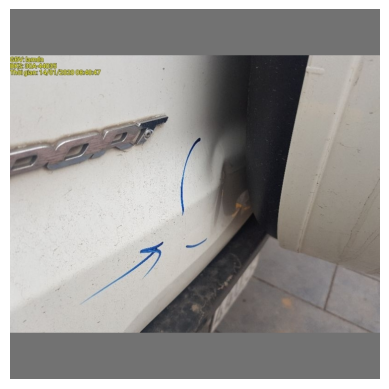

In [ ]:
#lets visualise the image

image_name = first_label_file.stem + ".jpg"
image_path = images_folder / "train" / image_name

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
yaml_content = f"""
path: {vehide_folder}
train: images/train
val: images/val
test: images/test

names:
  0: dent
  1: scratch
  2: crack
  3: broken_lamp
  4: shattered_glass
  5: flat_tyre
"""

new_yaml_path = Path("/content/vehide_seg.yaml")
new_yaml_path.write_text(yaml_content)

print(new_yaml_path.read_text())


path: /root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1/vehide_seg
train: images/train
val: images/val
test: images/test

names:
  0: dent
  1: scratch
  2: crack
  3: broken_lamp
  4: shattered_glass
  5: flat_tyre



# Section 3: Model Training & Hyperparameter Tuning

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO(str(RUNS_DIR / RUN_NAME / "weights" / "last.pt"))

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
results = model.train(
    data=str(new_yaml_path),
    epochs=EPOCHS,
    patience=PATIENCE,
    imgsz=IMGSZ,
    batch=BATCH,
    seed=SEED,
    project=str(RUNS_DIR),
    name=RUN_NAME+"_Extended"
)

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehide_seg.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/vehide_seg/runs/yolo11m_seg_vehide/weight

In [ ]:
val_model = YOLO(str(RUNS_DIR / str(RUN_NAME) / "weights" / "best.pt"))

metrics = val_model.val()

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLO11m-seg summary (fused): 139 layers, 22,339,938 parameters, 0 gradients, 113.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11731.1±2412.6 MB/s, size: 376.7 KB)
val: Scanning /root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1/vehide_seg/labels/val.cache... 2047 images, 139 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2047/2047 1.2Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 14.0it/s 9.2s
                   all       2047       5042      0.524      0.444      0.438      0.269      0.512      0.408      0.401      0.209
                  dent        659        846      0.461      0.246      0.245      0.108       0.45      0.219      0.222     0.0888
               scratch       1029       2212       0.

In [ ]:
import pandas as pd

results_csv = RUNS_DIR / str(RUN_NAME) / "results.csv"
print(results_csv.exists())

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()
print(df.columns.tolist())

True
['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'train/sem_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'val/sem_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


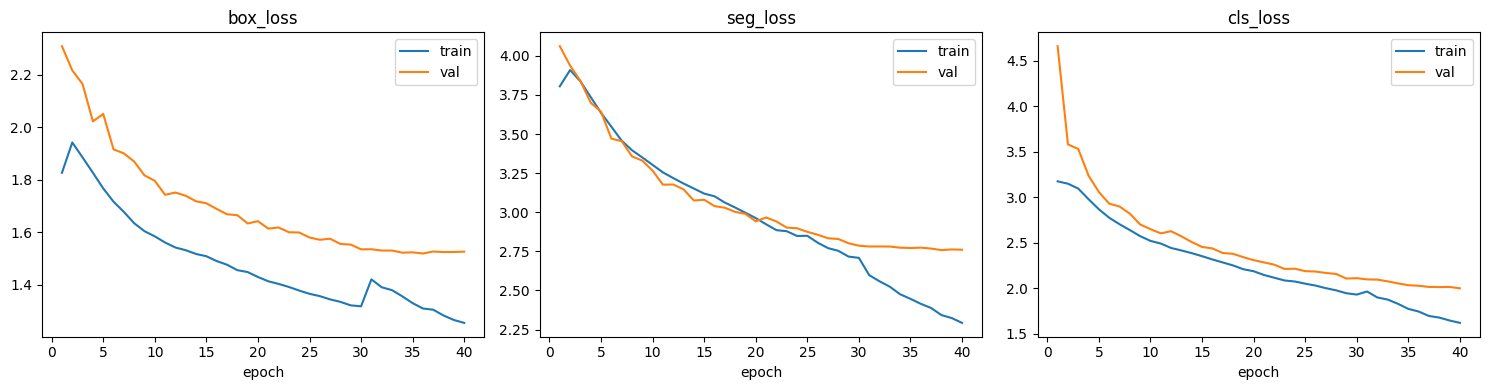

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

loss_pairs = [("box_loss", axes[0]), ("seg_loss", axes[1]), ("cls_loss", axes[2])]

for loss_name, ax in loss_pairs:
    ax.plot(df["epoch"], df[f"train/{loss_name}"], label="train")
    ax.plot(df["epoch"], df[f"val/{loss_name}"], label="val")
    ax.set_title(loss_name)
    ax.set_xlabel("epoch")
    ax.legend()

plt.tight_layout()
plt.show()

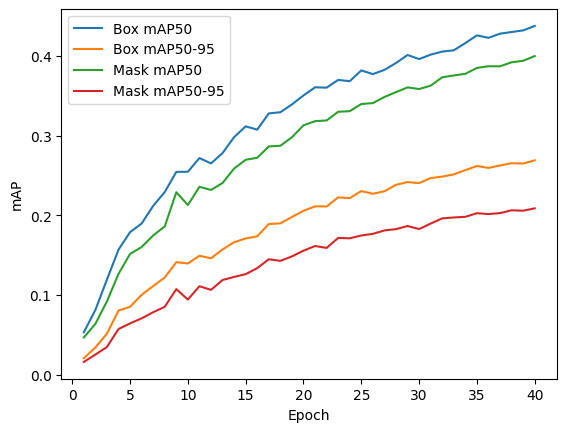

In [ ]:
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="Box mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="Box mAP50-95")
plt.plot(df["epoch"], df["metrics/mAP50(M)"], label="Mask mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(M)"], label="Mask mAP50-95")

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.legend()
plt.show()

## Hyperparameter tuning with Optuna

Search a small space of hyperparameters (learning rate, weight decay, rotation augmentation) using short 5-epoch trials, then use the best combination for a full training run.

In [ ]:
%pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 27.3 MB/s eta 0:00:00


In [ ]:
import optuna
from ultralytics import YOLO

def objective(trial):
    lr0 = trial.suggest_float("lr0", 0.00005, 0.01, log=True)
    weight_decay = trial.suggest_float("weight_decay", 0.0, 0.001)
    degrees = trial.suggest_float("degrees", 0.0, 15.0)

    model = YOLO(MODEL_NAME)

    results = model.train(
        data=str(new_yaml_path),
        epochs=5,
        imgsz=IMGSZ,
        batch=BATCH,
        seed=SEED,
        optimizer="AdamW",
        lr0=lr0,
        weight_decay=weight_decay,
        degrees=degrees,
        project=str(RUNS_DIR),
        name=f"optuna_trial_V2_{trial.number}",
        verbose=False,
    )

    mask_map50 = results.results_dict["metrics/mAP50(M)"]
    return mask_map50

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
sampler = optuna.samplers.TPESampler(n_startup_trials=8, seed=SEED)

study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=12)

print("Best params:", study.best_params)
print("Best mask mAP50:", study.best_value)

[I 2026-08-04 14:00:54,356] A new study created in memory with name: no-name-6602d199-ac36-433a-9cf2-9620c67af58d


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehide_seg.yaml, degrees=10.979909127171076, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.00036374585440139074, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=op

[I 2026-08-04 14:49:28,289] Trial 0 finished with value: 0.30634402577898884 and parameters: {'lr0': 0.00036374585440139074, 'weight_decay': 0.0009507143064099162, 'degrees': 10.979909127171076}. Best is trial 0 with value: 0.30634402577898884.


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehide_seg.yaml, degrees=2.3399178050430396, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0011926173789223548, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=opt

[I 2026-08-04 15:37:30,774] Trial 1 finished with value: 0.21250902166088412 and parameters: {'lr0': 0.0011926173789223548, 'weight_decay': 0.00015601864044243653, 'degrees': 2.3399178050430396}. Best is trial 0 with value: 0.30634402577898884.


...

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehide_seg.yaml, degrees=14.20442814585224, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003391249525017594, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=optu

[I 2026-08-04 22:48:51,345] Trial 10 finished with value: 0.30527328086616407 and parameters: {'lr0': 0.0003391249525017594, 'weight_decay': 0.0006240835271723652, 'degrees': 14.20442814585224}. Best is trial 7 with value: 0.3510569058725917.


Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehide_seg.yaml, degrees=6.599238067924237, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=5.158083507890073e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=optu

[I 2026-08-04 23:37:08,261] Trial 11 finished with value: 0.3472117013207598 and parameters: {'lr0': 5.158083507890073e-05, 'weight_decay': 0.0009776004699219654, 'degrees': 6.599238067924237}. Best is trial 7 with value: 0.3510569058725917.


Best params: {'lr0': 0.00010470069436968718, 'weight_decay': 0.00029214464853521814, 'degrees': 5.495427649405375}
Best mask mAP50: 0.3510569058725917


## Training model on tuned parameters

In [ ]:
model = YOLO(MODEL_NAME)

results = model.train(
    data=str(new_yaml_path),
    epochs=40,
    patience=PATIENCE,
    imgsz=IMGSZ,
    batch=BATCH,
    seed=SEED,
    optimizer="AdamW",
    lr0=0.0001047,
    weight_decay=0.000292,
    degrees=5.5,
    project=str(RUNS_DIR),
    name=RUN_NAME + "_tuned",
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vehide_seg.yaml, degrees=5.5, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001047, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m_seg_vehide_tuned, nbs

In [ ]:
import pandas as pd

results_csv = RUNS_DIR / str(RUN_NAME + "_tuned") / "results.csv"
print(results_csv.exists())

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()
print(df.columns.tolist())

True
['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'train/sem_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'val/sem_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


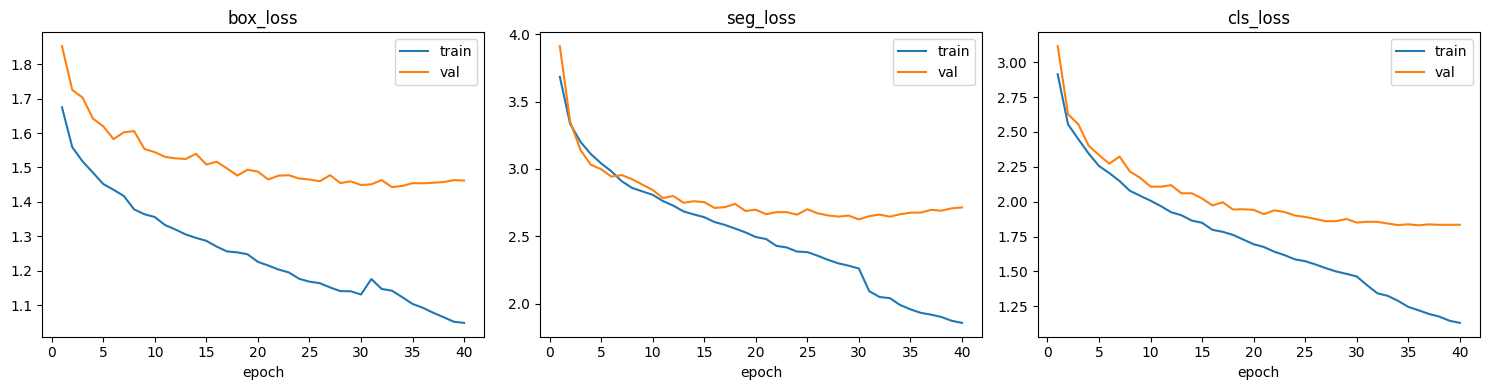

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

loss_pairs = [("box_loss", axes[0]), ("seg_loss", axes[1]), ("cls_loss", axes[2])]

for loss_name, ax in loss_pairs:
    ax.plot(df["epoch"], df[f"train/{loss_name}"], label="train")
    ax.plot(df["epoch"], df[f"val/{loss_name}"], label="val")
    ax.set_title(loss_name)
    ax.set_xlabel("epoch")
    ax.legend()

plt.tight_layout()
plt.show()